# Supervised Learning – Baseline Model Comparison

This notebook establishes baseline supervised learning models
for diabetes risk prediction.

The objective of this stage is **model benchmarking**:
- compare multiple classification algorithms on the same dataset,
- evaluate their predictive performance,
- select a suitable model for subsequent feature engineering
  and resampling experiments.

At this stage:
- no resampling is applied,
- no feature merging is applied,
- interpretability and robustness are prioritised.


## 1. Imports and Configuration

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

sns.set_style("whitegrid")


## 2. Load Dataset

In [2]:
X_train = pd.read_csv("X_train_smote_rfe.csv")
X_test = pd.read_csv("X_test_rfe.csv")
y_train = pd.read_csv("y_train_smote.csv")
y_test = pd.read_csv("y_test.csv")

X_train.shape

(341924, 7)

## 3. Target Variable and Class Distribution

The binary target variable is defined as:
- 0: non-diabetic
- 1: diabetic (including prediabetes)

after smote, class distribution is no more examined to assess imbalance.

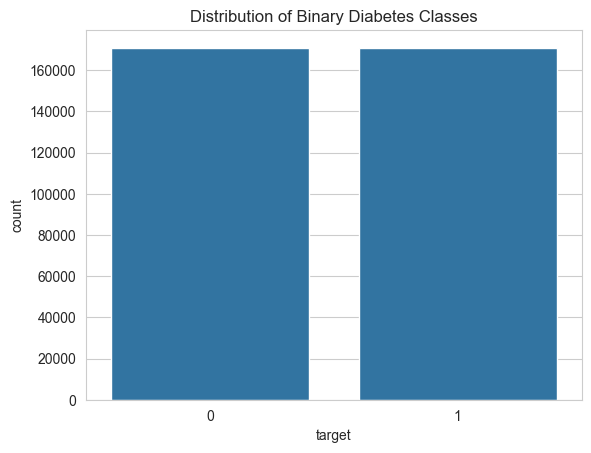

In [3]:
y_train.value_counts(normalize=True)
sns.countplot(x='target', data=y_train)
plt.title("Distribution of Binary Diabetes Classes")
plt.show()

## 4. Define Baseline Models

In this section, we evaluate a series of baseline classification models
(Logistic Regression, SVM, KNN, Random Forest, and XGBoost) using the
RFE-selected features.  
SMOTE is applied only on the training set to address class imbalance,
while the test set remains untouched to ensure fair evaluation.

All models are tuned using cross-validated grid search.
The best model for each algorithm is selected based on ROC-AUC,
and evaluated on the test set using Accuracy, AUC, F1-score,
Recall, and Precision.

In [4]:
y_train = y_train.values.ravel()
y_test = y_test.values.ravel()

In [6]:
from sklearn.metrics import (
    accuracy_score, roc_auc_score,
    f1_score, recall_score, precision_score
)

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)

    # 有些模型需要 predict_proba，有些用 decision_function
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "AUC": roc_auc_score(y_test, y_prob),
        "F1": f1_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred)
    }


## 4.1 LR

In [7]:
from sklearn.model_selection import GridSearchCV

# Logistic Regression with StandardScaler in Pipeline
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(solver="liblinear", max_iter=1000, random_state=42))
])

lr_param_grid = {
    'clf__C': [0.01, 0.1, 1, 10],
    'clf__penalty': ['l1', 'l2']
}

lr_gs = GridSearchCV(
    lr_pipe,
    lr_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

lr_gs.fit(X_train, y_train)

lr_best = lr_gs.best_estimator_
lr_result = evaluate_model(lr_best, X_test, y_test)


d:\anaconda3\envs\dm_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
d:\anaconda3\envs\dm_env\Lib\site-packages\sklearn\linear_model\_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


## 4.2 SVM

In [13]:
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV

svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(probability=True, random_state=42))
])

svm_param_grid = {
    'svc__C': [0.1, 1, 10],
    'svc__kernel': ['rbf'],
    'svc__gamma': ['scale', 'auto'],
    'svc__max_iter': [50000]
}

# Use successive halving to speed up search (fewer evaluations)
svm_gs = HalvingGridSearchCV(
    svm_pipe,
    svm_param_grid,
    scoring='roc_auc',
    cv=3,
    factor=2,
    n_jobs=-1,
    verbose=1
)

svm_gs.fit(X_train, y_train)

svm_best = svm_gs.best_estimator_
svm_result = evaluate_model(svm_best, X_test, y_test)


n_iterations: 3
n_required_iterations: 3
n_possible_iterations: 3
min_resources_: 85481
max_resources_: 341924
aggressive_elimination: False
factor: 2
----------
iter: 0
n_candidates: 6
n_resources: 85481
Fitting 3 folds for each of 6 candidates, totalling 18 fits


KeyboardInterrupt: 

too slow!!!!!! give it up

## 4.3 KNN

In [8]:
# KNN with StandardScaler in Pipeline
knn_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', KNeighborsClassifier())
])

knn_param_grid = {
    'clf__n_neighbors': [3, 5, 7, 11],
    'clf__weights': ['uniform', 'distance'],
    'clf__metric': ['euclidean', 'manhattan']
}

knn_gs = GridSearchCV(
    knn_pipe,
    knn_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1
)

knn_gs.fit(X_train, y_train)

knn_best = knn_gs.best_estimator_
knn_result = evaluate_model(knn_best, X_test, y_test)


## 4.4 RF

In [9]:
from sklearn.ensemble import RandomForestClassifier

# Random Forest with StandardScaler in Pipeline (scaling optional for trees)
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(random_state=42, n_jobs=-1))
])

rf_param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [None, 10, 20],
    'clf__min_samples_split': [2, 5],
    'clf__min_samples_leaf': [1, 2],
}

rf_gs = GridSearchCV(
    rf_pipe,
    rf_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

rf_gs.fit(X_train, y_train)

rf_best = rf_gs.best_estimator_
rf_result = evaluate_model(rf_best, X_test, y_test)


## 4.5 XGBoost

In [11]:
from xgboost import XGBClassifier

# XGBoost with StandardScaler in Pipeline (scaling usually unnecessary but added for consistency)
xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', XGBClassifier(objective="binary:logistic", eval_metric="auc", tree_method="hist", random_state=42))
])

xgb_param_grid = {
    'clf__n_estimators': [100, 300],
    'clf__max_depth': [3, 5],
    'clf__learning_rate': [0.01, 0.1],
    'clf__subsample': [0.8, 1.0],
    'clf__colsample_bytree': [0.8, 1.0],
}

xgb_gs = GridSearchCV(
    xgb_pipe,
    xgb_param_grid,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
)

xgb_gs.fit(X_train, y_train)

xgb_best = xgb_gs.best_estimator_
xgb_result = evaluate_model(xgb_best, X_test, y_test)


## 4.6 Final table

In [15]:
results_df = pd.DataFrame([
    {"Model": "Logistic Regression", **lr_result},
    {"Model": "KNN", **knn_result},
    {"Model": "Random Forest", **rf_result},
    {"Model": "XGBoost", **xgb_result},
])

results_df

,Model,Accuracy,AUC,F1,Recall,Precision
0,Logistic Regression,0.727038,0.812444,0.463778,0.749093,0.335857
1,KNN,0.837315,0.771694,0.335748,0.260913,0.470774
2,Random Forest,0.822375,0.802497,0.453884,0.468418,0.440226
3,XGBoost,0.835679,0.813999,0.432432,0.397248,0.474455


It can be seen that the accuracy, precision and ROC AUC of KNN are all lower than those of logistic regression, but the F1 score and recall of KNN are higher than those of logistic regression. Our goal is to identify as many diabetic patients as possible. Therefore, we tend to choose KNN with a higher recall, even if it means sacrificing a small portion of accuracy.

In [ ]:
best_models["KNN"]["model"].get_params()
best_models["Logistic Regression"]["model"].get_params()